Adapt the algorithm provided by Trefethen for the Allen-Cahn solver to create a generalized ETD solver that takes in a linear operator, a callable for the non-linear part, a function satisfying the boundary conditions, and a spatial mesh. 

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('../utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np 
from scipy import sparse 
from scipy import fft
from scipy.linalg import expm
from matplotlib import pyplot as plt
from matplotlib import animation
from time import time

from ETD_solver import cheb

In [3]:
def ETD(L, N, x, u0, alpha, beta, q, tf, nt):
    ''' 

        Parameters: 
            L (ndarray) : linear operator
            N (callable) : non-linear part 
            x (ndarray) : spatial mesh
            u0 (callable) : initial condition
            alpha (float) : value for left Dirichlet boundary 
            beta (float) : value for right Dirichlet boundary
            q (callable) : function satisfying boundary conditions 
            tf (float) : final time value 
            nt (int) : number of desired timesteps
        Returns: 
            U (ndarray) : solution 
            t (ndarray) : temporal mesh
    '''

    sl = np.s_[1:-1]                                                # interior slice
    nx = len(x) - 1                                                 # number of spatial nodes
    x = x[sl]                                                       # slice out interior of spatial domain
    t_vals, h = np.linspace(0, tf, nt+1, retstep=True)              # temporal mesh
    L = L[sl, sl]                                                   # slice out interior of linear operator

    # precompute ETD-RK4 matrix quantities (from Trefethen's Allen-Cahn algorithm)
    M = 32                                                          # number of points for resolvent integral
    r = (15. * 
         np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M))        # points along complex circle
    A = h * L 
    E = expm(A).astype(complex)
    E2 = expm(A / 2.).astype(complex)
    I = np.eye(nx-1).astype(complex)
    f1 = np.zeros((nx-1, nx-1)).astype(complex)
    f2 = np.zeros((nx-1, nx-1)).astype(complex)
    f3 = np.zeros((nx-1, nx-1)).astype(complex)
    Q = np.zeros((nx-1, nx-1)).astype(complex)
    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)
        Q += h * zIA * (np.exp(z / 2.) - 1.)
        f1 += h * zIA * (-4. - z + np.exp(z) * (4. - 3. * z + z**2)) / z**2
        f2 += h * zIA * (2. + z + np.exp(z) * (z - 2.)) / z**2
        f3 += h * zIA * (-4. - 3. * z - z**2 + np.exp(z) * (4. - z)) / z**2 
    f1 = np.real(f1 / M)
    f2 = np.real(f2 / M)
    f3 = np.real(f3 / M)
    Q = np.real(Q / M)

    # main solver
    U = np.empty((nt+1, nx+1))          # intialize solution array
    U[:, 0] = alpha                         # fix left boundary 
    U[:, -1] = beta                        # fix right boundary 
    U[0, sl] = u0(x)                    # set initial state
    qx = q(x)                           # evaluate function that satisfies the boundary 

    # time-stepping loop
    for t in range(1, nt+1):
        w = U[t-1, sl] - qx             # subtraction to make boundaries homogenous
        Nu = N(w + qx)
        a = E2 @ w + Q @ Nu 
        Na = N(a + qx)
        b = E2 @ w + Q @ Na 
        Nb = N(b + qx)
        c = E2 @ a + Q @ (2. * Nb - Nu)
        Nc = N(c + qx)
        w = E @ w + f1 @ Nu + 2. * f2 @ (Na + Nb) + f3 @ Nc

        # save new time-step
        U[t, sl] = np.real(w + qx)
    
    return U, t_vals

Test the solver on the Allen-Cahn equation, verify that the solutions look the same as the results using Trefethen's code:
$$u_t = 0.01u_{xx} + u - u^3$$
for $x \in [-1, 1]$ with $u(-1) = -1, u(1) = 1$.

In [35]:
N = 32                                                  # number of Chebyshev points to use in space
D, x = cheb(N)                                          # define the spatial grid and differential operator (Chebyshev)
L = 0.01 * (D @ D)                                      # define the linear operator 
N = lambda u : u - u**3                                 # non-linear part 
alpha = -1                                                  # left boundary 
beta = 1                                                   # right boundary 
q = lambda x : x                                        # function satisfying boundary conditions
# q = lambda x : np.concatenate([[alpha], np.zeros(len(x)-2), [beta]])
u0 = lambda x : (0.53 * x + 
                 0.47 * np.sin(-1.5 * np.pi * x))       # initial condition

tf = 70                                                 # final time 
nt = 70*4                                               # number of time-steps

U_allen_cahn, t_allen_cahn = ETD(L, N, x, u0, alpha, beta, q, tf, nt)

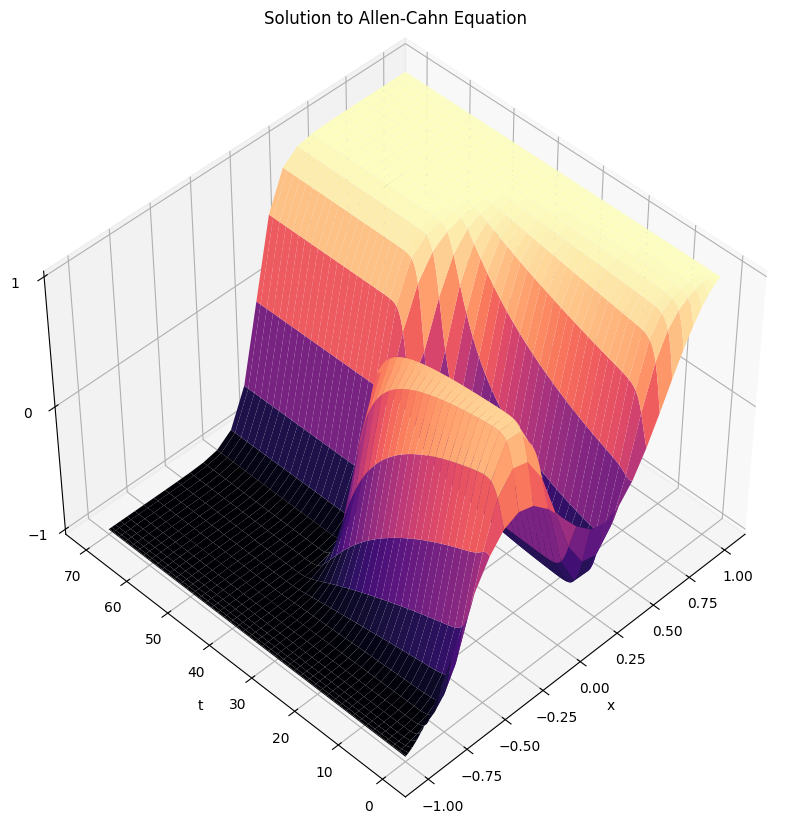

In [36]:
# plot as a 3D surface 
X, T = np.meshgrid(x, t_allen_cahn)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, T, U_allen_cahn, cmap="magma")
ax.view_init(elev=45, azim=(-45 - 90))
ax.set_zticks([-1, 0, 1])
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u")
ax.set_title("Solution to Allen-Cahn Equation")
plt.show()

Test on the heat equation (no non-linear term).

In [37]:
N = 32                                                  # number of Chebyshev points to use in space
D, x = cheb(N)                                          # define the spatial grid and differential operator (Chebyshev)
L = D @ D                                               # define the linear operator 
N = lambda u : np.zeros_like(u)                         # non-linear part 
q = lambda x : np.zeros_like(x)                         # function satisfying boundary conditions
u0 = lambda x: np.cos(np.pi * x / 2)                    # initial condition function
a = 0                                                   # left boundary 
b = 0                                                   # right boundary 
tf = 1                                                  # final time 
nt = 100                                                # number of time-steps

U_heat, t_heat = ETD(L, N, x, u0, a, b, q, tf, nt)

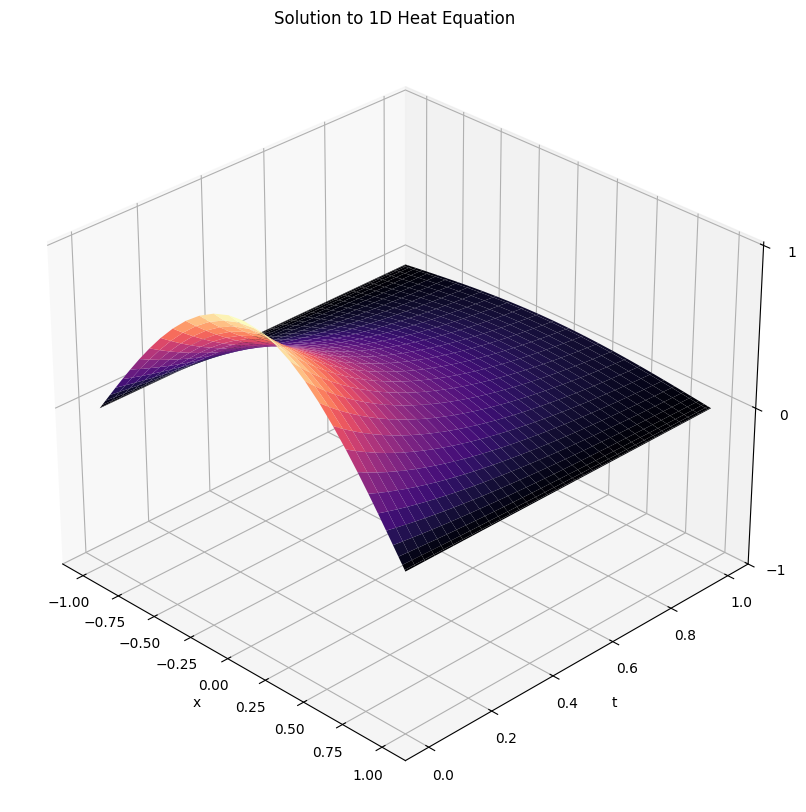

In [38]:
# plot as a 3D surface 
X, T = np.meshgrid(x, t_heat)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, T, U_heat, cmap="magma")
ax.view_init(elev=30, azim=-45)
ax.set_zticks([-1, 0, 1])
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u")
ax.set_title("Solution to 1D Heat Equation")
plt.show()

Fisher-KPP equation:
$$u_t = \nu u_{xx} + ru(1 - u)$$
for $x \in [-1, 1]$ with $u(-1) = 0, u(1) = 1$ and $u(x, 0) = \frac{1+x}{2}$.

In [66]:
# equation parameters 
nu = 0.01 
r = 1

N = 32                                                  # number of Chebyshev points to use in space
D, x = cheb(N)                                          # define the spatial grid and differential operator (Chebyshev)
L = nu * D @ D                                          # define the linear operator 

N = lambda u : r * u * (1. - u)                         # non-linear part 
a = 1                                                   # left boundary 
b = 0                                                   # right boundary 
q = lambda x : a + (b - a) * (x + 1) / 2.               # function satisfying boundary conditions
u0 = lambda x: (-x + 1.) / 2.                           # initial condition function

tf = 10                                                 # final time 
nt = 100                                                # number of time-steps

U_fisher_kpp, t_fisher_kpp = ETD(L, N, x, u0, a, b, q, tf, nt)

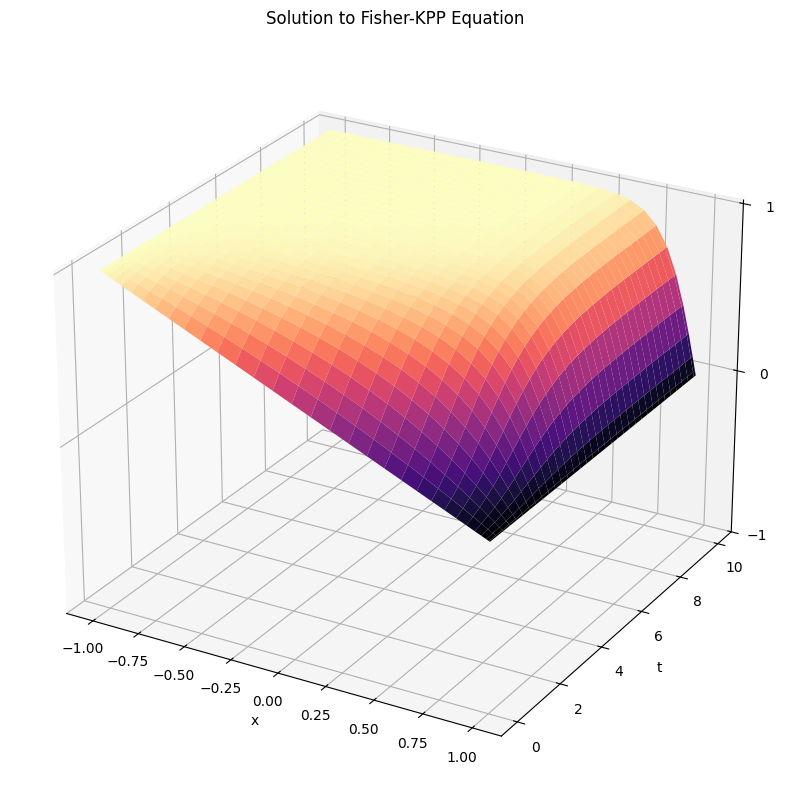

In [67]:
# plot as a 3D surface 
X, T = np.meshgrid(x, t_fisher_kpp)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, T, U_fisher_kpp, cmap="magma")
ax.view_init(elev=25, azim=-60)
ax.set_zticks([-1, 0, 1])
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u")
ax.set_title("Solution to Fisher-KPP Equation")
plt.show()

Burger's equation:
$$u_t = \nu u_{xx} - uu_x$$
for $x \in [-1, 1]$ with $u(-1) = 1, u(1) = -1$ and $u(x, 0) = -\sin{(\pi x)}$.

In [63]:
# equation parameters 
nu = 0.05

N = 32                                                      # number of Chebyshev points to use in space
D, x = cheb(N)                                              # define the spatial grid and differential operator (Chebyshev)
L = nu * D @ D                                              # define the linear operator 
alpha = 1                                                   # left boundary 
beta = -1                                                   # right boundary 
BC = np.array([a, b])

# non-linear part 
def N(u):
    u = np.concatenate([[alpha], u, [beta]])
    new_u = -1 * u * (D @ u)
    return new_u[1:-1]

q = lambda x : alpha + (beta - alpha) * (x + 1) / 2.        # function satisfying boundary conditions
u0 = lambda x: -1*np.sin(np.pi * x / 2.)                    # initial condition function

tf = 1.5                                                      # final time 
nt = 1000                                                   # number of time-steps

U_burgers, t_burgers = ETD(L, N, x, u0, alpha, beta, q, tf, nt)

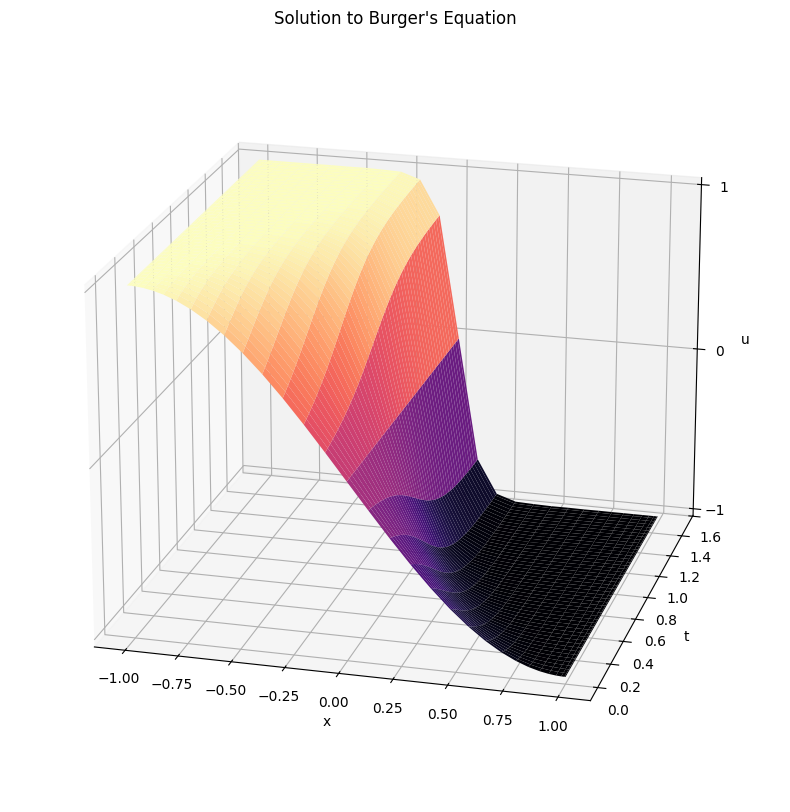

In [64]:
# plot as a 3D surface 
X, T = np.meshgrid(x, t_burgers)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, T, U_burgers, cmap="magma")
ax.view_init(elev=20, azim=-75)
ax.set_zticks([-1, 0, 1])
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u")
ax.set_title("Solution to Burger's Equation")
plt.show()

Plot all the solutions in one figure. 

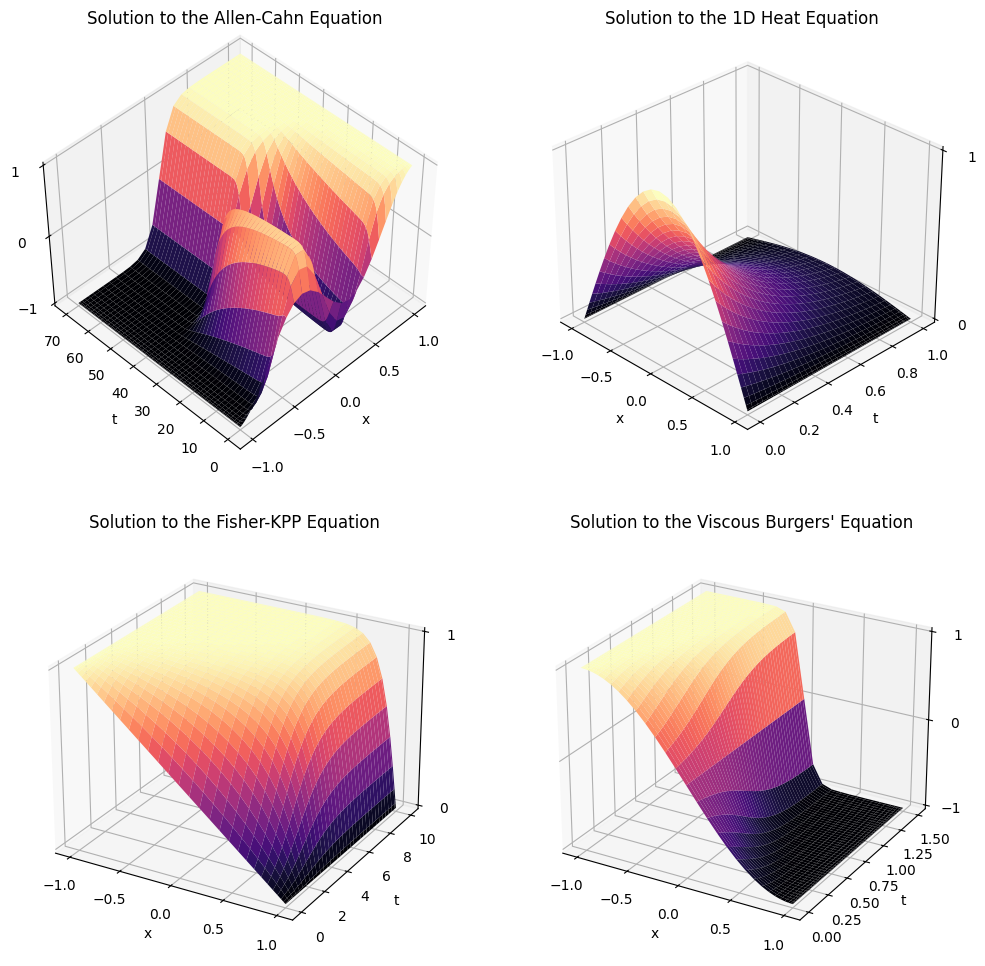

In [70]:
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221, projection="3d")     # Allen-Cahn
ax2 = fig.add_subplot(222, projection="3d")     # heat
ax3 = fig.add_subplot(223, projection="3d")     # Fisher-KPP
ax4 = fig.add_subplot(224, projection="3d")     # Burger's

# plot Allen-Cahn solution
X, T = np.meshgrid(x, t_allen_cahn)

ax1.plot_surface(X, T, U_allen_cahn, cmap="magma")
ax1.view_init(elev=45, azim=(-45 - 90))
ax1.set_zticks([-1, 0, 1])
ax1.set_xticks([-1, -0.5, 0, 0.5, 1])
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_title("Solution to the Allen-Cahn Equation")

# plot heat equation solution
X, T = np.meshgrid(x, t_heat)

ax2.plot_surface(X, T, U_heat, cmap="magma")
ax2.view_init(elev=30, azim=-45)
ax2.set_zticks([0, 1])
ax2.set_xticks([-1, -0.5, 0, 0.5, 1])
ax2.set_xlabel("x")
ax2.set_ylabel("t")
ax2.set_title("Solution to the 1D Heat Equation")

# plot Fisher-KPP solution
X, T = np.meshgrid(x, t_fisher_kpp)

ax3.plot_surface(X, T, U_fisher_kpp, cmap="magma")
ax3.view_init(elev=25, azim=-60)
ax3.set_zticks([0, 1])
ax3.set_xticks([-1, -0.5, 0, 0.5, 1])
ax3.set_yticks([0, 2, 4, 6, 8, 10])
ax3.set_xlabel("x")
ax3.set_ylabel("t")
ax3.set_title("Solution to the Fisher-KPP Equation")

# plot Burgers' solution
X, T = np.meshgrid(x, t_burgers)

ax4.plot_surface(X, T, U_burgers, cmap="magma")
ax4.view_init(elev=25, azim=-60)
ax4.set_zticks([-1, 0, 1])
ax4.set_xticks([-1, -0.5, 0, 0.5, 1])
ax4.set_yticks([0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])
ax4.set_xlabel("x")
ax4.set_ylabel("t")
ax4.set_title("Solution to the Viscous Burgers' Equation")

# plt.tight_layout()
plt.savefig("../plots/all_ETD_sols.png", dpi=300)
plt.show()

Analyze convergence for the heat equation.

In [71]:
nu = 1                                                  # diffusion coefficient
N = lambda u : np.zeros_like(u)                         # non-linear part 
q = lambda x : np.zeros_like(x)                         # function satisfying boundary conditions
u0 = lambda x: np.sin(np.pi * x)                        # initial condition function
a = 0                                                   # left boundary 
b = 0                                                   # right boundary 
tf = 1                                                  # final time 
nt = 100                                                # number of time-steps

# analytic solution
u_analytic = lambda x, t : np.sin(np.pi * x) * np.exp(-nu * np.pi**2 * t)

In [77]:
N_cheb = 4                                              # number of Chebyshev points to use
D, x = cheb(N_cheb)                                     # define the spatial grid and differential operator (Chebyshev)
L = nu * D @ D                                          # define the linear operator 
U_approx, t_vals = ETD(L, N, x, u0, a, b, q, tf, nt)    # get approximate solution

In [82]:
U_true = np.array([u_analytic(x, t) for t in t_vals])                       # compute analytic solution on the same grid 
rel_error = np.linalg.norm(U_true - U_approx) / np.linalg.norm(U_true)      # compute relative error at grid points
print(rel_error)

0.12527602095373552


In [117]:
# method to compute error over multiple values of N_cheb
def compute_errors(max_pow=4):
    
    # values to use for number of Chebyshev nodes
    N_cheb_vals = 2 ** np.arange(1, max_pow+1)

    nu = 1                                                  # diffusion coefficient
    N = lambda u : np.zeros_like(u)                         # non-linear part 
    q = lambda x : np.zeros_like(x)                         # function satisfying boundary conditions
    u0 = lambda x: np.sin(np.pi * x)                        # initial condition function
    a = 0                                                   # left boundary 
    b = 0                                                   # right boundary 
    tf = 1                                                  # final time 
    # nt = 100                                                # number of time-steps
    

    # analytic solution
    u_analytic = lambda x, t : np.sin(np.pi * x) * np.exp(-nu * np.pi**2 * t)

    # initialize array to store errors
    errors = np.empty_like(N_cheb_vals, dtype=np.float64)

    for i, N_cheb in enumerate(N_cheb_vals):
        nt = max(100, 10 * N_cheb)  # or some other scaling
        D, x = cheb(N_cheb)                                     # define the spatial grid and differential operator (Chebyshev)
        L = nu * D @ D                                          # define the linear operator 
        U_approx, t_vals = ETD(L, N, x, u0, a, b, q, tf, nt)    # get approximate solution
        U_true = np.array([u_analytic(x, t) for t in t_vals])                       # compute analytic solution on the same grid 
        rel_error = np.linalg.norm(U_true - U_approx) / np.linalg.norm(U_true)      # compute relative error at grid points

        # save error
        errors[i] = rel_error

    return errors, N_cheb_vals

In [118]:
errors, N = compute_errors(max_pow=7)

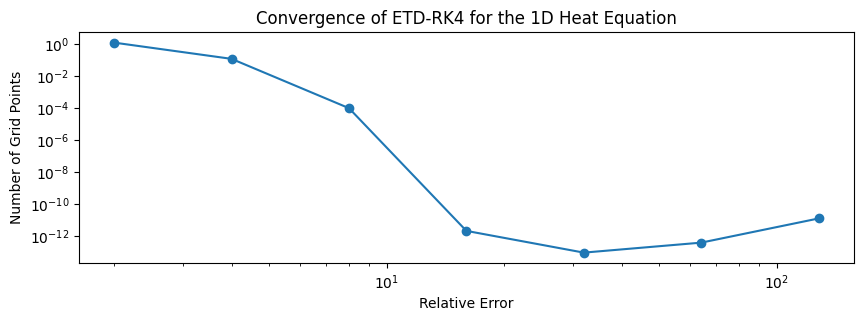

In [122]:
plt.figure(figsize=(10, 3))
plt.loglog(N, errors, marker="o")
plt.xlabel("Relative Error")
plt.ylabel("Number of Grid Points")
plt.title("Convergence of ETD-RK4 for the 1D Heat Equation")
plt.savefig("../plots/etd_rk4_convergence.png", dpi=300)
plt.show()